<a href="https://colab.research.google.com/github/emanalzaanin/Assignments/blob/main/TimeSeriesAnalysis_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Analysis - London Weather Data

In [ ]:
# 1. Load the data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/london_weather.csv')
# 2. Convert the date column to datetime dtype
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# 3. Set the date column as the index
df = df.set_index('date')

# 4. Filter out only the required data
# Keep only data from the year 2000 or later
df = df.loc['2000':]

# Keep only the required features
features = ['precipitation', 'mean_temp', 'min_temp', 'max_temp', 'snow_depth']
df = df[features]

# 5. Impute any missing values
# Temperatures: Linear interpolation
df['mean_temp'] = df['mean_temp'].interpolate(method='linear')
df['min_temp'] = df['min_temp'].interpolate(method='linear')
df['max_temp'] = df['max_temp'].interpolate(method='linear')

# Precipitation and Snow Depth: Fill with 0
df['precipitation'] = df['precipitation'].fillna(0)
df['snow_depth'] = df['snow_depth'].fillna(0)

print("Missing values after imputation:")
print(df.isna().sum())
df.head()

Missing values after imputation:
precipitation    0
mean_temp        0
min_temp         0
max_temp         0
snow_depth       0
dtype: int64


,precipitation,mean_temp,min_temp,max_temp,snow_depth
date,,,,,
2000-01-01,0.0,7.0,4.9,10.8,0.0
2000-01-02,0.2,7.9,5.0,11.5,0.0
2000-01-03,6.0,9.4,7.2,9.5,0.0
2000-01-04,0.2,7.0,4.4,11.0,0.0
2000-01-05,0.8,6.4,1.9,10.8,0.0


## Part 1: Load the data and make a datetime index

## Part 2: Answer the Questions with Visualizations

### Q1: What month had the most precipitation between 2000 through 2010?

Max Precipitation: 155.40 inches on October 2000


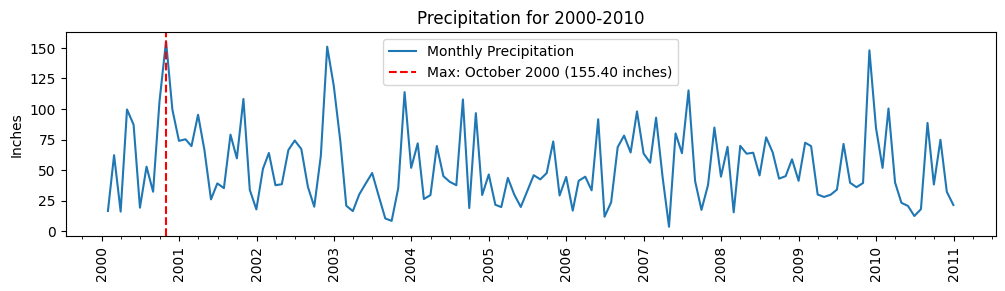

In [7]:
# Filter for 2000-2010
df_q1 = df.loc['2000':'2010'].copy()

# Resample the precipitation column to a Monthly frequency using .sum()
precip_monthly = df_q1['precipitation'].resample('ME').sum()

# Find the date and corresponding value for the max precipitation
max_precip_val = precip_monthly.max()
max_precip_date = precip_monthly.idxmax()

print(f"Max Precipitation: {max_precip_val:.2f} inches on {max_precip_date.strftime('%B %Y')}")

# Visualization Requirements
fig, ax = plt.subplots(figsize=(12, 3))

# Plot the feature
ax.plot(precip_monthly.index, precip_monthly.values, label='Monthly Precipitation')

# Add a vertical line at this date with a label
ax.axvline(max_precip_date, color='red', linestyle='--',
           label=f"Max: {max_precip_date.strftime('%B %Y')} ({max_precip_val:.2f} inches)")

# Customization
ax.set_title("Precipitation for 2000-2010")
ax.set_ylabel("Inches")

# Major ticks: every 1 year, 4-digit years, 90 deg rotation
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=90)

# Minor ticks: every 3 months, no labels
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

ax.legend()
fig.autofmt_xdate(rotation=90, ha='center')
plt.show()

### Q2: Which year between 2000-2020 had the coolest average temperature?

Coolest Year: 2010 with Average Temp: 10.64 Degrees


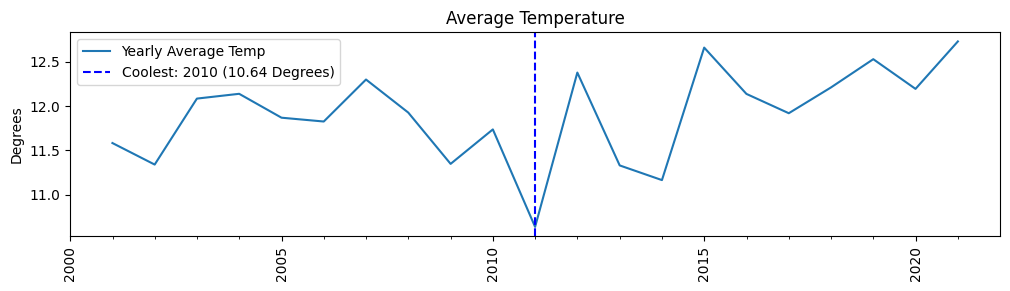

In [9]:
# Filter for 2000-2020
df_q2 = df.loc['2000':'2020'].copy()

# Resample the mean_temp data to a Yearly frequency using .mean()
temp_yearly = df_q2['mean_temp'].resample('YE').mean()

# Determine the year and value for the lowest mean temp
min_temp_val = temp_yearly.min()
min_temp_year = temp_yearly.idxmin()

print(f"Coolest Year: {min_temp_year.year} with Average Temp: {min_temp_val:.2f} Degrees")

# Visualization Requirements
fig, ax = plt.subplots(figsize=(12, 3))

# Plot the feature
ax.plot(temp_yearly.index, temp_yearly.values, label='Yearly Average Temp')

# Add a vertical line at this date with a label
ax.axvline(min_temp_year, color='blue', linestyle='--',
           label=f"Coolest: {min_temp_year.year} ({min_temp_val:.2f} Degrees)")

# Customization
ax.set_title("Average Temperature")
ax.set_ylabel("Degrees")

# Major ticks: every 5 years, 4-digit years, 90 deg rotation
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=90)

# Minor ticks: every 1 year, no labels
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

ax.legend()
fig.autofmt_xdate(rotation=90, ha='center')
plt.show()